In [1]:
!pip -q install networkx

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import json
import os

SEED = 42

print("Libraries loaded.")

Libraries loaded.


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Notebook2_MEDH096_outputs.zip to Notebook2_MEDH096_outputs.zip


In [4]:
!unzip -o /content/Notebook2_MEDH096_outputs.zip -d /content/Notebook3_input

Archive:  /content/Notebook2_MEDH096_outputs.zip
  inflating: /content/Notebook3_input/MEDH_096_attention_pair.npz  
  inflating: /content/Notebook3_input/MEDH_096_tokens.json  
  inflating: /content/Notebook3_input/MEDH_096_metadata.json  


In [5]:
print(
    os.listdir("/content/Notebook3_input")
)

['MEDH_096_tokens.json', 'MEDH_096_metadata.json', 'MEDH_096_attention_pair.npz']


In [6]:
ATTENTION_FILE = (
    "/content/Notebook3_input/"
    "MEDH_096_attention_pair.npz"
)

TOKEN_FILE = (
    "/content/Notebook3_input/"
    "MEDH_096_tokens.json"
)

META_FILE = (
    "/content/Notebook3_input/"
    "MEDH_096_metadata.json"
)

attention_data = np.load(ATTENTION_FILE)

with open(TOKEN_FILE, "r") as f:
    token_data = json.load(f)

with open(META_FILE, "r") as f:
    metadata = json.load(f)

print("Available matrices:")
print(attention_data.files)

print("\nPair:", metadata["Pair_ID"])
print("Difficulty:", metadata["Difficulty"])
print(
    "Hallucination category:",
    metadata["Hallucination_Category"]
)

Available matrices:
['factual_last', 'factual_last4', 'factual_all', 'hallucinated_last', 'hallucinated_last4', 'hallucinated_all']

Pair: MEDH_096
Difficulty: easy
Hallucination category: Misinterpretation of #Question#


In [7]:
A_factual = attention_data[
    "factual_last4"
]

A_hallucinated = attention_data[
    "hallucinated_last4"
]

factual_tokens = token_data[
    "factual_tokens"
]

hallucinated_tokens = token_data[
    "hallucinated_tokens"
]

print(
    "Factual matrix:",
    A_factual.shape
)

print(
    "Hallucinated matrix:",
    A_hallucinated.shape
)

print(
    "Factual tokens:",
    len(factual_tokens)
)

print(
    "Hallucinated tokens:",
    len(hallucinated_tokens)
)

Factual matrix: (58, 58)
Hallucinated matrix: (53, 53)
Factual tokens: 58
Hallucinated tokens: 53


In [8]:
assert A_factual.shape[0] == A_factual.shape[1]
assert (
    A_hallucinated.shape[0]
    ==
    A_hallucinated.shape[1]
)

assert (
    A_factual.shape[0]
    ==
    len(factual_tokens)
)

assert (
    A_hallucinated.shape[0]
    ==
    len(hallucinated_tokens)
)

assert np.isfinite(A_factual).all()
assert np.isfinite(A_hallucinated).all()

print(
    "ATTENTION DATA VALIDATION PASSED"
)

ATTENTION DATA VALIDATION PASSED


In [9]:
def build_attention_graph(
    attention_matrix,
    tokens,
    top_k=5
):

    A = np.asarray(
        attention_matrix,
        dtype=np.float64
    )

    n = len(tokens)

    assert A.shape == (n, n)

    G = nx.DiGraph()

    # Add token-position nodes
    for i, token in enumerate(tokens):
        G.add_node(
            i,
            token=str(token),
            position=i
        )

    # A[target, source]
    # becomes source -> target
    for target in range(n):

        weights = A[target].copy()

        # Remove self-attention edge
        weights[target] = 0.0

        positive_sources = np.where(
            weights > 0
        )[0]

        if len(positive_sources) == 0:
            continue

        k = min(
            top_k,
            len(positive_sources)
        )

        ranked_sources = positive_sources[
            np.argsort(
                weights[positive_sources]
            )[::-1][:k]
        ]

        for source in ranked_sources:

            weight = float(
                weights[source]
            )

            G.add_edge(
                int(source),
                int(target),
                weight=weight,

                # Larger attention = shorter
                # effective network distance
                distance=1.0 / (
                    weight + 1e-12
                )
            )

    return G

In [10]:
TOP_K = 5

G_factual = build_attention_graph(
    A_factual,
    factual_tokens,
    top_k=TOP_K
)

G_hallucinated = build_attention_graph(
    A_hallucinated,
    hallucinated_tokens,
    top_k=TOP_K
)

print(
    "FACTUAL GRAPH"
)

print(
    "Nodes:",
    G_factual.number_of_nodes()
)

print(
    "Edges:",
    G_factual.number_of_edges()
)

print(
    "\nHALLUCINATED GRAPH"
)

print(
    "Nodes:",
    G_hallucinated.number_of_nodes()
)

print(
    "Edges:",
    G_hallucinated.number_of_edges()
)

FACTUAL GRAPH
Nodes: 58
Edges: 275

HALLUCINATED GRAPH
Nodes: 53
Edges: 250


In [11]:
def graph_summary(G, graph_name):

    n = G.number_of_nodes()
    m = G.number_of_edges()

    weights = [
        d["weight"]
        for _, _, d
        in G.edges(data=True)
    ]

    if len(G) > 0:
        largest_component = max(
            nx.weakly_connected_components(G),
            key=len
        )

        largest_fraction = (
            len(largest_component) / n
        )
    else:
        largest_fraction = np.nan

    return {
        "Graph": graph_name,
        "Nodes": n,
        "Edges": m,
        "Density": nx.density(G),
        "Mean_Edge_Weight":
            np.mean(weights)
            if weights else np.nan,
        "Total_Retained_Attention":
            np.sum(weights)
            if weights else np.nan,
        "Largest_WCC_Fraction":
            largest_fraction
    }

In [12]:
summary_df = pd.DataFrame([
    graph_summary(
        G_factual,
        "Factual"
    ),
    graph_summary(
        G_hallucinated,
        "Hallucinated"
    )
])

display(summary_df)

,Graph,Nodes,Edges,Density,Mean_Edge_Weight,Total_Retained_Attention,Largest_WCC_Fraction
0,Factual,58,275,0.083182,0.156818,43.125006,1.0
1,Hallucinated,53,250,0.090711,0.158423,39.605790,1.0


In [13]:
def token_strength_table(G):

    rows = []

    for node in G.nodes():

        token = G.nodes[node]["token"]

        out_strength = sum(
            data["weight"]
            for _, _, data
            in G.out_edges(
                node,
                data=True
            )
        )

        in_strength = sum(
            data["weight"]
            for _, _, data
            in G.in_edges(
                node,
                data=True
            )
        )

        rows.append({
            "Position": node,
            "Token": token,
            "Out_Strength":
                out_strength,
            "In_Strength":
                in_strength
        })

    return pd.DataFrame(rows)

In [14]:
factual_strength = (
    token_strength_table(
        G_factual
    )
)

hall_strength = (
    token_strength_table(
        G_hallucinated
    )
)

In [15]:
display(
    factual_strength
    .sort_values(
        "Out_Strength",
        ascending=False
    )
    .head(15)
)

,Position,Token,Out_Strength,In_Strength
0,0,<bos>,35.326633,0.000000
1,1,<start_of_turn>,1.049514,0.811035
3,3,\n,0.555417,0.767385
18,18,▁pancreatitis,0.416915,0.771054
21,21,\n,0.395399,0.794919
7,7,lin,0.313603,0.846740
22,22,<start_of_turn>,0.288466,0.688567
39,39,▁aggravating,0.266310,0.688737
13,13,▁in,0.237938,0.826118
4,4,Is,0.216136,0.885144


In [16]:
display(
    factual_strength
    .sort_values(
        "Out_Strength",
        ascending=False
    )
    .head(15)
)

,Position,Token,Out_Strength,In_Strength
0,0,<bos>,35.326633,0.000000
1,1,<start_of_turn>,1.049514,0.811035
3,3,\n,0.555417,0.767385
18,18,▁pancreatitis,0.416915,0.771054
21,21,\n,0.395399,0.794919
7,7,lin,0.313603,0.846740
22,22,<start_of_turn>,0.288466,0.688567
39,39,▁aggravating,0.266310,0.688737
13,13,▁in,0.237938,0.826118
4,4,Is,0.216136,0.885144


In [17]:
display(
    hall_strength
    .sort_values(
        "Out_Strength",
        ascending=False
    )
    .head(15)
)

,Position,Token,Out_Strength,In_Strength
0,0,<bos>,32.395797,0.000000
1,1,<start_of_turn>,1.012573,0.811035
3,3,\n,0.555417,0.767385
18,18,▁pancreatitis,0.420400,0.771054
7,7,lin,0.313374,0.846740
42,42,▁promoting,0.296914,0.691015
13,13,▁in,0.237938,0.826118
36,36,▁of,0.227522,0.725807
23,23,model,0.224267,0.782160
4,4,Is,0.216136,0.885144


In [18]:
CONTROL_TOKENS = {
    "<bos>",
    "<start_of_turn>",
    "<end_of_turn>",
    "user",
    "model",
    "\n"
}

def semantic_tokens_only(df):

    return df[
        ~df["Token"].isin(
            CONTROL_TOKENS
        )
    ].copy()

In [19]:
factual_semantic = (
    semantic_tokens_only(
        factual_strength
    )
)

hall_semantic = (
    semantic_tokens_only(
        hall_strength
    )
)

print("Top factual semantic tokens:")

display(
    factual_semantic
    .sort_values(
        "Out_Strength",
        ascending=False
    )
    .head(10)
)

print(
    "Top hallucinated semantic tokens:"
)

display(
    hall_semantic
    .sort_values(
        "Out_Strength",
        ascending=False
    )
    .head(10)
)

Top factual semantic tokens:


,Position,Token,Out_Strength,In_Strength
18,18,▁pancreatitis,0.416915,0.771054
7,7,lin,0.313603,0.846740
39,39,▁aggravating,0.266310,0.688737
13,13,▁in,0.237938,0.826118
4,4,Is,0.216136,0.885144
31,31,lin,0.178732,0.659684
50,50,▁on,0.168607,0.704036
28,28,▁that,0.166922,0.714081
11,11,▁aggravating,0.155428,0.829941
47,47,▁through,0.145811,0.705302


Top hallucinated semantic tokens:


,Position,Token,Out_Strength,In_Strength
18,18,▁pancreatitis,0.420400,0.771054
7,7,lin,0.313374,0.846740
42,42,▁promoting,0.296914,0.691015
13,13,▁in,0.237938,0.826118
36,36,▁of,0.227522,0.725807
4,4,Is,0.216136,0.885144
27,27,lin,0.185092,0.700851
40,40,▁pancreatitis,0.166830,0.655211
32,32,▁in,0.162399,0.709977
31,31,▁crucial,0.146550,0.684578


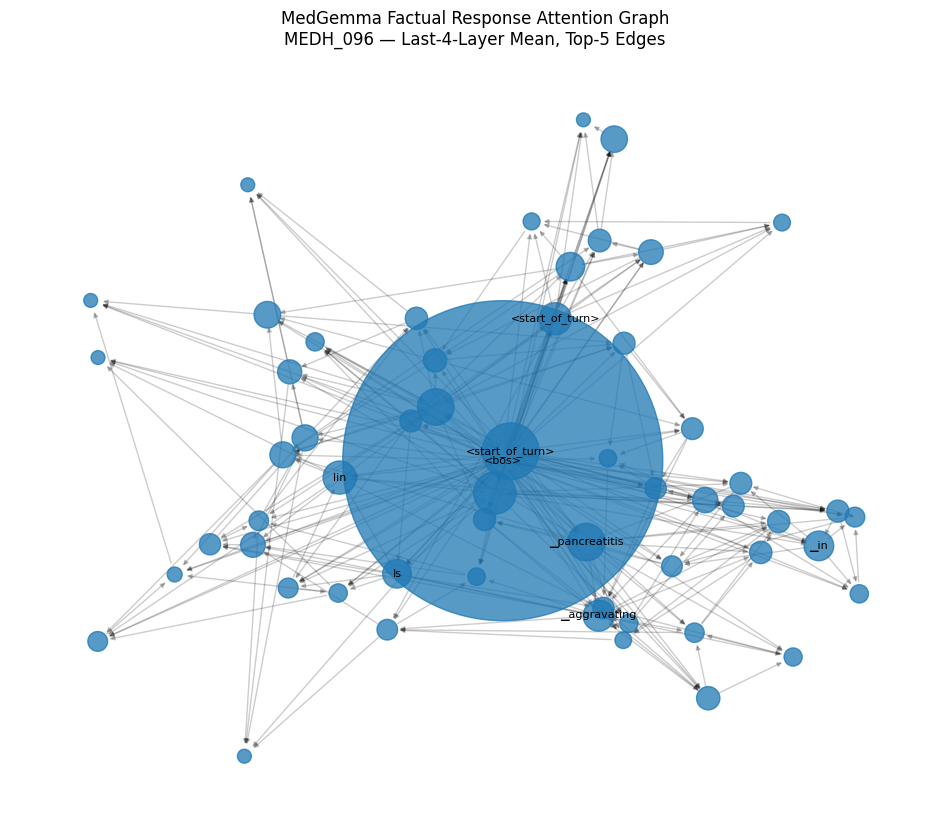

In [20]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G_factual,
    seed=SEED,
    weight="weight"
)

node_strength = dict(
    G_factual.out_degree(
        weight="weight"
    )
)

node_sizes = [
    100
    +
    1500 * node_strength[n]
    for n in G_factual.nodes()
]

nx.draw_networkx_nodes(
    G_factual,
    pos,
    node_size=node_sizes,
    alpha=0.75
)

nx.draw_networkx_edges(
    G_factual,
    pos,
    alpha=0.20,
    arrows=True,
    arrowsize=7
)

top_nodes = sorted(
    node_strength,
    key=node_strength.get,
    reverse=True
)[:10]

labels = {
    n: G_factual.nodes[n]["token"]
    for n in top_nodes
}

nx.draw_networkx_labels(
    G_factual,
    pos,
    labels=labels,
    font_size=8
)

plt.title(
    "MedGemma Factual Response Attention Graph\n"
    "MEDH_096 — Last-4-Layer Mean, Top-5 Edges"
)

plt.axis("off")
plt.show()

In [ ]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G_hallucinated,
    seed=SEED,
    weight="weight"
)

node_strength = dict(
    G_hallucinated.out_degree(
        weight="weight"
    )
)

node_sizes = [
    100
    +
    1500 * node_strength[n]
    for n in G_hallucinated.nodes()
]

nx.draw_networkx_nodes(
    G_hallucinated,
    pos,
    node_size=node_sizes,
    alpha=0.75
)

nx.draw_networkx_edges(
    G_hallucinated,
    pos,
    alpha=0.20,
    arrows=True,
    arrowsize=7
)

top_nodes = sorted(
    node_strength,
    key=node_strength.get,
    reverse=True
)[:10]

labels = {
    n:
    G_hallucinated.nodes[n]["token"]
    for n in top_nodes
}

nx.draw_networkx_labels(
    G_hallucinated,
    pos,
    labels=labels,
    font_size=8
)

plt.title(
    "MedGemma Hallucinated Response Attention Graph\n"
    "MEDH_096 — Last-4-Layer Mean, Top-5 Edges"
)

plt.axis("off")
plt.show()

In [21]:
OUTPUT_DIR = "/content/Notebook3_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

nx.write_graphml(
    G_factual,
    f"{OUTPUT_DIR}/"
    "MEDH_096_factual.graphml"
)

nx.write_graphml(
    G_hallucinated,
    f"{OUTPUT_DIR}/"
    "MEDH_096_hallucinated.graphml"
)

summary_df.to_csv(
    f"{OUTPUT_DIR}/"
    "MEDH_096_graph_summary.csv",
    index=False
)

factual_strength.to_csv(
    f"{OUTPUT_DIR}/"
    "MEDH_096_factual_strength.csv",
    index=False
)

hall_strength.to_csv(
    f"{OUTPUT_DIR}/"
    "MEDH_096_hallucinated_strength.csv",
    index=False
)

print("Notebook 3 outputs saved.")

Notebook 3 outputs saved.


In [22]:
CONTROL_TOKENS = {
    "<bos>",
    "<start_of_turn>",
    "<end_of_turn>",
    "user",
    "model",
    "\n"
}

def remove_control_tokens(A, tokens):
    """
    Remove chat/control token rows and columns
    and renormalize remaining attention rows.
    """

    keep_indices = [
        i for i, token in enumerate(tokens)
        if token not in CONTROL_TOKENS
    ]

    A_clean = A[np.ix_(keep_indices, keep_indices)]

    clean_tokens = [
        tokens[i] for i in keep_indices
    ]

    # Renormalize each target row after removing control tokens
    row_sums = A_clean.sum(axis=1, keepdims=True)

    A_clean = np.divide(
        A_clean,
        row_sums,
        out=np.zeros_like(A_clean),
        where=row_sums != 0
    )

    return A_clean, clean_tokens

In [23]:
A_factual_sem, factual_tokens_sem = remove_control_tokens(
    A_factual,
    factual_tokens
)

A_hall_sem, hallucinated_tokens_sem = remove_control_tokens(
    A_hallucinated,
    hallucinated_tokens
)

print("Original factual:", A_factual.shape)
print("Semantic factual:", A_factual_sem.shape)

print("Original hallucinated:", A_hallucinated.shape)
print("Semantic hallucinated:", A_hall_sem.shape)

Original factual: (58, 58)
Semantic factual: (47, 47)
Original hallucinated: (53, 53)
Semantic hallucinated: (42, 42)


In [24]:
G_factual_sem = build_attention_graph(
    A_factual_sem,
    factual_tokens_sem,
    top_k=5
)

G_hall_sem = build_attention_graph(
    A_hall_sem,
    hallucinated_tokens_sem,
    top_k=5
)

print("FACTUAL SEMANTIC GRAPH")
print("Nodes:", G_factual_sem.number_of_nodes())
print("Edges:", G_factual_sem.number_of_edges())

print("\nHALLUCINATED SEMANTIC GRAPH")
print("Nodes:", G_hall_sem.number_of_nodes())
print("Edges:", G_hall_sem.number_of_edges())

FACTUAL SEMANTIC GRAPH
Nodes: 47
Edges: 220

HALLUCINATED SEMANTIC GRAPH
Nodes: 42
Edges: 195


In [25]:
factual_sem_strength = token_strength_table(
    G_factual_sem
)

hall_sem_strength = token_strength_table(
    G_hall_sem
)

print("TOP FACTUAL TOKENS")
display(
    factual_sem_strength
    .sort_values("Out_Strength", ascending=False)
    .head(15)
)

print("TOP HALLUCINATED TOKENS")
display(
    hall_sem_strength
    .sort_values("Out_Strength", ascending=False)
    .head(15)
)

TOP FACTUAL TOKENS


,Position,Token,Out_Strength,In_Strength
3,3,lin,1.500905,0.477514
14,14,▁pancreatitis,1.432143,0.356374
0,0,Is,1.186216,0.000000
9,9,▁in,0.888191,0.361207
7,7,▁aggravating,0.785318,0.446162
30,30,▁aggravating,0.727135,0.395022
19,19,▁that,0.616742,0.343340
8,8,▁factor,0.570762,0.480948
18,18,▁suggest,0.562403,0.340411
1,1,▁end,0.526551,0.460419


TOP HALLUCINATED TOKENS


,Position,Token,Out_Strength,In_Strength
14,14,▁pancreatitis,1.461271,0.356374
3,3,lin,1.413349,0.477514
0,0,Is,1.172228,0.000000
9,9,▁in,0.888191,0.361207
33,33,▁promoting,0.804969,0.297619
27,27,▁of,0.714009,0.433823
7,7,▁aggravating,0.628188,0.446162
18,18,lin,0.583481,0.383208
6,6,▁an,0.567190,0.441834
8,8,▁factor,0.560260,0.480948


In [26]:
def get_qa_indices(tokens):

    # Find user section
    user_start = None
    model_start = None

    for i in range(len(tokens) - 1):

        if (
            tokens[i] == "<start_of_turn>"
            and tokens[i + 1] == "user"
        ):
            user_start = i + 2

        if (
            tokens[i] == "<start_of_turn>"
            and tokens[i + 1] == "model"
        ):
            model_start = i + 2
            break

    if user_start is None or model_start is None:
        raise ValueError("Chat markers not found.")

    # Skip newline after role marker
    if tokens[user_start] == "\n":
        user_start += 1

    if tokens[model_start] == "\n":
        model_start += 1

    # Question ends at first end_of_turn
    question_end = next(
        i for i in range(user_start, len(tokens))
        if tokens[i] == "<end_of_turn>"
    )

    # Answer ends at next end_of_turn
    answer_end = next(
        (
            i for i in range(model_start, len(tokens))
            if tokens[i] == "<end_of_turn>"
        ),
        len(tokens)
    )

    question_indices = list(
        range(user_start, question_end)
    )

    answer_indices = list(
        range(model_start, answer_end)
    )

    return question_indices, answer_indices

In [27]:
fq_idx, fa_idx = get_qa_indices(
    factual_tokens
)

hq_idx, ha_idx = get_qa_indices(
    hallucinated_tokens
)

print("Factual question tokens:", len(fq_idx))
print("Factual answer tokens:", len(fa_idx))

print("Hallucinated question tokens:", len(hq_idx))
print("Hallucinated answer tokens:", len(ha_idx))

Factual question tokens: 16
Factual answer tokens: 31
Hallucinated question tokens: 16
Hallucinated answer tokens: 26


In [28]:
print("FACTUAL QUESTION TOKENS")
print([factual_tokens[i] for i in fq_idx])

print("\nHALLUCINATED QUESTION TOKENS")
print([hallucinated_tokens[i] for i in hq_idx])

FACTUAL QUESTION TOKENS
['Is', '▁end', 'othe', 'lin', '-', '1', '▁an', '▁aggravating', '▁factor', '▁in', '▁the', '▁development', '▁of', '▁acute', '▁pancreatitis', '?']

HALLUCINATED QUESTION TOKENS
['Is', '▁end', 'othe', 'lin', '-', '1', '▁an', '▁aggravating', '▁factor', '▁in', '▁the', '▁development', '▁of', '▁acute', '▁pancreatitis', '?']


In [29]:
def create_word_groups(tokens, token_indices):

    groups = []
    current_group = []

    for idx in token_indices:

        token = tokens[idx]

        # A ▁ generally marks the beginning
        # of a new SentencePiece word.
        starts_new_word = token.startswith("▁")

        if starts_new_word:

            if current_group:
                groups.append(current_group)

            current_group = [idx]

        else:

            if not current_group:
                current_group = [idx]
            else:
                current_group.append(idx)

    if current_group:
        groups.append(current_group)

    return groups

In [30]:
factual_word_groups = create_word_groups(
    factual_tokens,
    fa_idx
)

hall_word_groups = create_word_groups(
    hallucinated_tokens,
    ha_idx
)

print(
    "Factual answer words:",
    len(factual_word_groups)
)

print(
    "Hallucinated answer words:",
    len(hall_word_groups)
)

Factual answer words: 24
Hallucinated answer words: 18


In [31]:
import string

def group_to_word(tokens, group):

    pieces = [
        tokens[i].replace("▁", "")
        for i in group
    ]

    word = "".join(pieces)

    # Clean only external punctuation for display
    word = word.strip()

    return word

In [32]:
factual_words = [
    group_to_word(
        factual_tokens,
        group
    )
    for group in factual_word_groups
]

hall_words = [
    group_to_word(
        hallucinated_tokens,
        group
    )
    for group in hall_word_groups
]

print("FACTUAL WORDS:")
print(factual_words)

print("\nHALLUCINATED WORDS:")
print(hall_words)

FACTUAL WORDS:
['These', 'results', 'suggest', 'that', 'endothelin-1', 'should', 'play', 'a', 'role', 'in', 'aggravating', 'the', 'development', 'of', 'acute', 'hemorrhagic', 'pancreatitis,', 'through', 'its', 'action', 'on', 'the', 'pancreatic', 'microcirculation.']

HALLUCINATED WORDS:
['Endothelin-1', 'is', 'crucial', 'in', 'the', 'early', 'stages', 'of', 'edematous', 'pancreatitis,', 'promoting', 'fluid', 'accumulation', 'rather', 'than', 'in', 'hemorrhagic', 'transformation.']


In [33]:
factual_words = [
    group_to_word(
        factual_tokens,
        group
    )
    for group in factual_word_groups
]

hall_words = [
    group_to_word(
        hallucinated_tokens,
        group
    )
    for group in hall_word_groups
]

print("FACTUAL WORDS:")
print(factual_words)

print("\nHALLUCINATED WORDS:")
print(hall_words)

FACTUAL WORDS:
['These', 'results', 'suggest', 'that', 'endothelin-1', 'should', 'play', 'a', 'role', 'in', 'aggravating', 'the', 'development', 'of', 'acute', 'hemorrhagic', 'pancreatitis,', 'through', 'its', 'action', 'on', 'the', 'pancreatic', 'microcirculation.']

HALLUCINATED WORDS:
['Endothelin-1', 'is', 'crucial', 'in', 'the', 'early', 'stages', 'of', 'edematous', 'pancreatitis,', 'promoting', 'fluid', 'accumulation', 'rather', 'than', 'in', 'hemorrhagic', 'transformation.']


In [34]:
import numpy as np

def token_to_word_attention(
    A,
    word_groups
):

    n_words = len(word_groups)

    A_word = np.zeros(
        (n_words, n_words),
        dtype=np.float64
    )

    for target_word, target_group in enumerate(
        word_groups
    ):

        for source_word, source_group in enumerate(
            word_groups
        ):

            block = A[
                np.ix_(
                    target_group,
                    source_group
                )
            ]

            # Sum source pieces,
            # average target pieces
            value = (
                block
                .sum(axis=1)
                .mean()
            )

            A_word[
                target_word,
                source_word
            ] = value

    return A_word

In [35]:
A_factual_word = token_to_word_attention(
    A_factual,
    factual_word_groups
)

A_hall_word = token_to_word_attention(
    A_hallucinated,
    hall_word_groups
)

print(
    "Factual word matrix:",
    A_factual_word.shape
)

print(
    "Hallucinated word matrix:",
    A_hall_word.shape
)

Factual word matrix: (24, 24)
Hallucinated word matrix: (18, 18)


In [36]:
def question_attention_support(
    A,
    question_indices,
    answer_indices
):

    block = A[
        np.ix_(
            answer_indices,
            question_indices
        )
    ]

    per_answer_token = block.sum(axis=1)

    return {
        "Mean_QAS":
            float(per_answer_token.mean()),

        "Median_QAS":
            float(np.median(per_answer_token)),

        "Std_QAS":
            float(per_answer_token.std())
    }

In [37]:
qas_factual = question_attention_support(
    A_factual,
    fq_idx,
    fa_idx
)

qas_hall = question_attention_support(
    A_hallucinated,
    hq_idx,
    ha_idx
)

print("FACTUAL QAS:")
print(qas_factual)

print("\nHALLUCINATED QAS:")
print(qas_hall)

FACTUAL QAS:
{'Mean_QAS': 0.0647275298833847, 'Median_QAS': 0.05437059700489044, 'Std_QAS': 0.031040135771036148}

HALLUCINATED QAS:
{'Mean_QAS': 0.0669226348400116, 'Median_QAS': 0.06342196464538574, 'Std_QAS': 0.024205151945352554}


In [38]:
qas_factual = question_attention_support(
    A_factual,
    fq_idx,
    fa_idx
)

qas_hall = question_attention_support(
    A_hallucinated,
    hq_idx,
    ha_idx
)

print("FACTUAL QAS:")
print(qas_factual)

print("\nHALLUCINATED QAS:")
print(qas_hall)

FACTUAL QAS:
{'Mean_QAS': 0.0647275298833847, 'Median_QAS': 0.05437059700489044, 'Std_QAS': 0.031040135771036148}

HALLUCINATED QAS:
{'Mean_QAS': 0.0669226348400116, 'Median_QAS': 0.06342196464538574, 'Std_QAS': 0.024205151945352554}


In [39]:
import networkx as nx

def build_word_graph(
    A_word,
    words,
    top_k=3
):

    G = nx.DiGraph()

    n = len(words)

    for i, word in enumerate(words):

        G.add_node(
            i,
            word=word,
            position=i
        )

    for target in range(n):

        weights = A_word[target].copy()

        # no self-edge
        weights[target] = 0.0

        positive = np.where(
            weights > 0
        )[0]

        if len(positive) == 0:
            continue

        k = min(
            top_k,
            len(positive)
        )

        sources = positive[
            np.argsort(
                weights[positive]
            )[::-1][:k]
        ]

        for source in sources:

            weight = float(
                weights[source]
            )

            G.add_edge(
                int(source),
                int(target),
                weight=weight,
                distance=1.0 /
                (weight + 1e-12)
            )

    return G

In [40]:
TOP_K_WORD = 3

G_factual_word = build_word_graph(
    A_factual_word,
    factual_words,
    top_k=TOP_K_WORD
)

G_hall_word = build_word_graph(
    A_hall_word,
    hall_words,
    top_k=TOP_K_WORD
)

print("FACTUAL WORD GRAPH")
print(
    "Nodes:",
    G_factual_word.number_of_nodes()
)
print(
    "Edges:",
    G_factual_word.number_of_edges()
)

print("\nHALLUCINATED WORD GRAPH")
print(
    "Nodes:",
    G_hall_word.number_of_nodes()
)
print(
    "Edges:",
    G_hall_word.number_of_edges()
)

FACTUAL WORD GRAPH
Nodes: 24
Edges: 66

HALLUCINATED WORD GRAPH
Nodes: 18
Edges: 48


In [41]:
TOP_K_WORD = 3

G_factual_word = build_word_graph(
    A_factual_word,
    factual_words,
    top_k=TOP_K_WORD
)

G_hall_word = build_word_graph(
    A_hall_word,
    hall_words,
    top_k=TOP_K_WORD
)

print("FACTUAL WORD GRAPH")
print(
    "Nodes:",
    G_factual_word.number_of_nodes()
)
print(
    "Edges:",
    G_factual_word.number_of_edges()
)

print("\nHALLUCINATED WORD GRAPH")
print(
    "Nodes:",
    G_hall_word.number_of_nodes()
)
print(
    "Edges:",
    G_hall_word.number_of_edges()
)

FACTUAL WORD GRAPH
Nodes: 24
Edges: 66

HALLUCINATED WORD GRAPH
Nodes: 18
Edges: 48


In [42]:
def word_strength_table(G):

    rows = []

    for node in G.nodes():

        word = G.nodes[node]["word"]

        out_strength = sum(
            data["weight"]
            for _, _, data
            in G.out_edges(
                node,
                data=True
            )
        )

        in_strength = sum(
            data["weight"]
            for _, _, data
            in G.in_edges(
                node,
                data=True
            )
        )

        rows.append({
            "Position": node,
            "Word": word,
            "Out_Strength":
                out_strength,
            "In_Strength":
                in_strength
        })

    return pd.DataFrame(rows)

In [43]:
factual_word_strength = (
    word_strength_table(
        G_factual_word
    )
)

hall_word_strength = (
    word_strength_table(
        G_hall_word
    )
)

print("TOP FACTUAL ANSWER WORDS")

display(
    factual_word_strength
    .sort_values(
        "Out_Strength",
        ascending=False
    )
    .head(15)
)

print("TOP HALLUCINATED ANSWER WORDS")

display(
    hall_word_strength
    .sort_values(
        "Out_Strength",
        ascending=False
    )
    .head(15)
)

TOP FACTUAL ANSWER WORDS


,Position,Word,Out_Strength,In_Strength
4,4,endothelin-1,0.239517,0.060710
10,10,aggravating,0.233185,0.088473
17,17,through,0.145811,0.074805
9,9,in,0.140519,0.072963
16,16,"pancreatitis,",0.135265,0.055552
20,20,on,0.133656,0.082126
14,14,acute,0.106586,0.104264
6,6,play,0.105966,0.102243
13,13,of,0.103807,0.083583
21,21,the,0.099140,0.117903


TOP HALLUCINATED ANSWER WORDS


,Position,Word,Out_Strength,In_Strength
10,10,promoting,0.279588,0.089639
9,9,"pancreatitis,",0.238715,0.082800
3,3,in,0.162399,0.078389
4,4,the,0.137606,0.126627
8,8,edematous,0.136645,0.088870
0,0,Endothelin-1,0.135948,0.000000
2,2,crucial,0.120657,0.098551
5,5,early,0.094229,0.145163
11,11,fluid,0.093876,0.147827
1,1,is,0.081257,0.048378


In [44]:
factual_word_strength = (
    word_strength_table(
        G_factual_word
    )
)

hall_word_strength = (
    word_strength_table(
        G_hall_word
    )
)

print("TOP FACTUAL ANSWER WORDS")

display(
    factual_word_strength
    .sort_values(
        "Out_Strength",
        ascending=False
    )
    .head(15)
)

print("TOP HALLUCINATED ANSWER WORDS")

display(
    hall_word_strength
    .sort_values(
        "Out_Strength",
        ascending=False
    )
    .head(15)
)

TOP FACTUAL ANSWER WORDS


,Position,Word,Out_Strength,In_Strength
4,4,endothelin-1,0.239517,0.060710
10,10,aggravating,0.233185,0.088473
17,17,through,0.145811,0.074805
9,9,in,0.140519,0.072963
16,16,"pancreatitis,",0.135265,0.055552
20,20,on,0.133656,0.082126
14,14,acute,0.106586,0.104264
6,6,play,0.105966,0.102243
13,13,of,0.103807,0.083583
21,21,the,0.099140,0.117903


TOP HALLUCINATED ANSWER WORDS


,Position,Word,Out_Strength,In_Strength
10,10,promoting,0.279588,0.089639
9,9,"pancreatitis,",0.238715,0.082800
3,3,in,0.162399,0.078389
4,4,the,0.137606,0.126627
8,8,edematous,0.136645,0.088870
0,0,Endothelin-1,0.135948,0.000000
2,2,crucial,0.120657,0.098551
5,5,early,0.094229,0.145163
11,11,fluid,0.093876,0.147827
1,1,is,0.081257,0.048378


In [45]:
import matplotlib.pyplot as plt

def plot_word_graph(
    G,
    title
):

    plt.figure(figsize=(12, 9))

    pos = nx.spring_layout(
        G,
        seed=42,
        weight="weight"
    )

    strength = dict(
        G.out_degree(
            weight="weight"
        )
    )

    node_sizes = [
        250 +
        1100 * np.sqrt(
            max(strength[n], 0)
        )
        for n in G.nodes()
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        alpha=0.8
    )

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.25,
        arrows=True,
        arrowsize=9
    )

    labels = {
        n: G.nodes[n]["word"]
        for n in G.nodes()
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=8
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

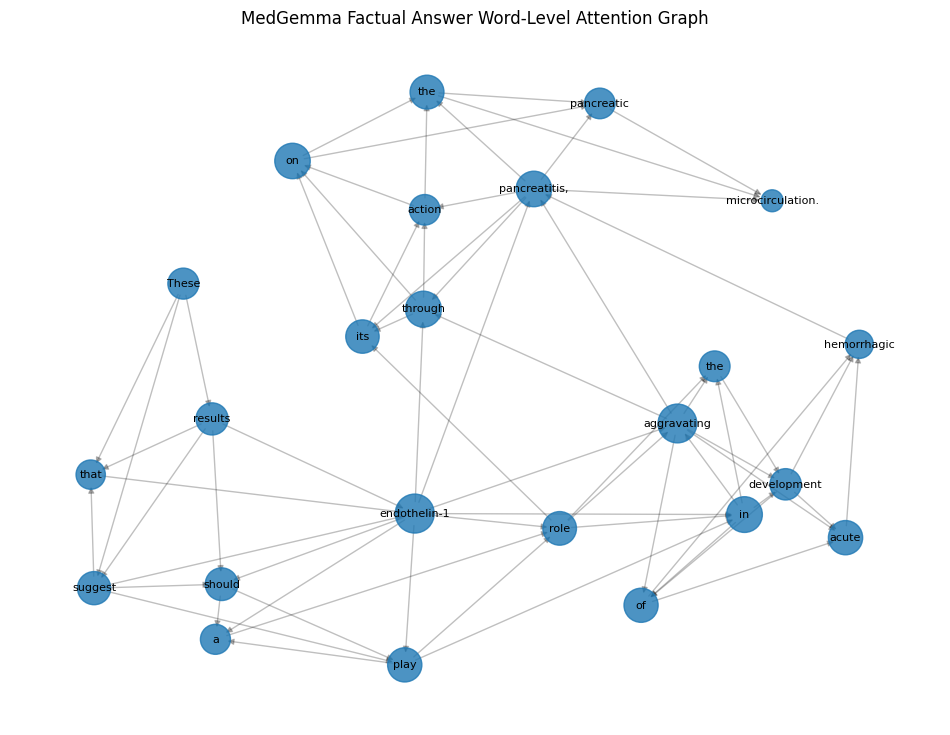

In [46]:
plot_word_graph(
    G_factual_word,
    "MedGemma Factual Answer Word-Level Attention Graph"
)

In [47]:
import re

def clean_word_label(word):
    return re.sub(r'^[^\w]+|[^\w-]+$', '', word)

factual_words_clean = [
    clean_word_label(w)
    for w in factual_words
]

hall_words_clean = [
    clean_word_label(w)
    for w in hall_words
]

print(factual_words_clean)
print(hall_words_clean)

['These', 'results', 'suggest', 'that', 'endothelin-1', 'should', 'play', 'a', 'role', 'in', 'aggravating', 'the', 'development', 'of', 'acute', 'hemorrhagic', 'pancreatitis', 'through', 'its', 'action', 'on', 'the', 'pancreatic', 'microcirculation']
['Endothelin-1', 'is', 'crucial', 'in', 'the', 'early', 'stages', 'of', 'edematous', 'pancreatitis', 'promoting', 'fluid', 'accumulation', 'rather', 'than', 'in', 'hemorrhagic', 'transformation']


In [48]:
G_factual_word = build_word_graph(
    A_factual_word,
    factual_words_clean,
    top_k=3
)

G_hall_word = build_word_graph(
    A_hall_word,
    hall_words_clean,
    top_k=3
)

In [49]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def plot_word_graph_colored(
    G,
    title,
    node_color,
    edge_color,
    label_color="black"
):
    plt.figure(figsize=(12, 9))

    pos = nx.spring_layout(
        G,
        seed=42,
        weight="weight"
    )

    strength = dict(
        G.out_degree(weight="weight")
    )

    node_sizes = [
        300 + 1200 * np.sqrt(max(strength[n], 0))
        for n in G.nodes()
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_color,
        alpha=0.90
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=edge_color,
        alpha=0.35,
        arrows=True,
        arrowsize=10,
        width=1.4
    )

    labels = {
        n: G.nodes[n]["word"]
        for n in G.nodes()
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=8,
        font_color=label_color
    )

    plt.title(title, fontsize=15, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

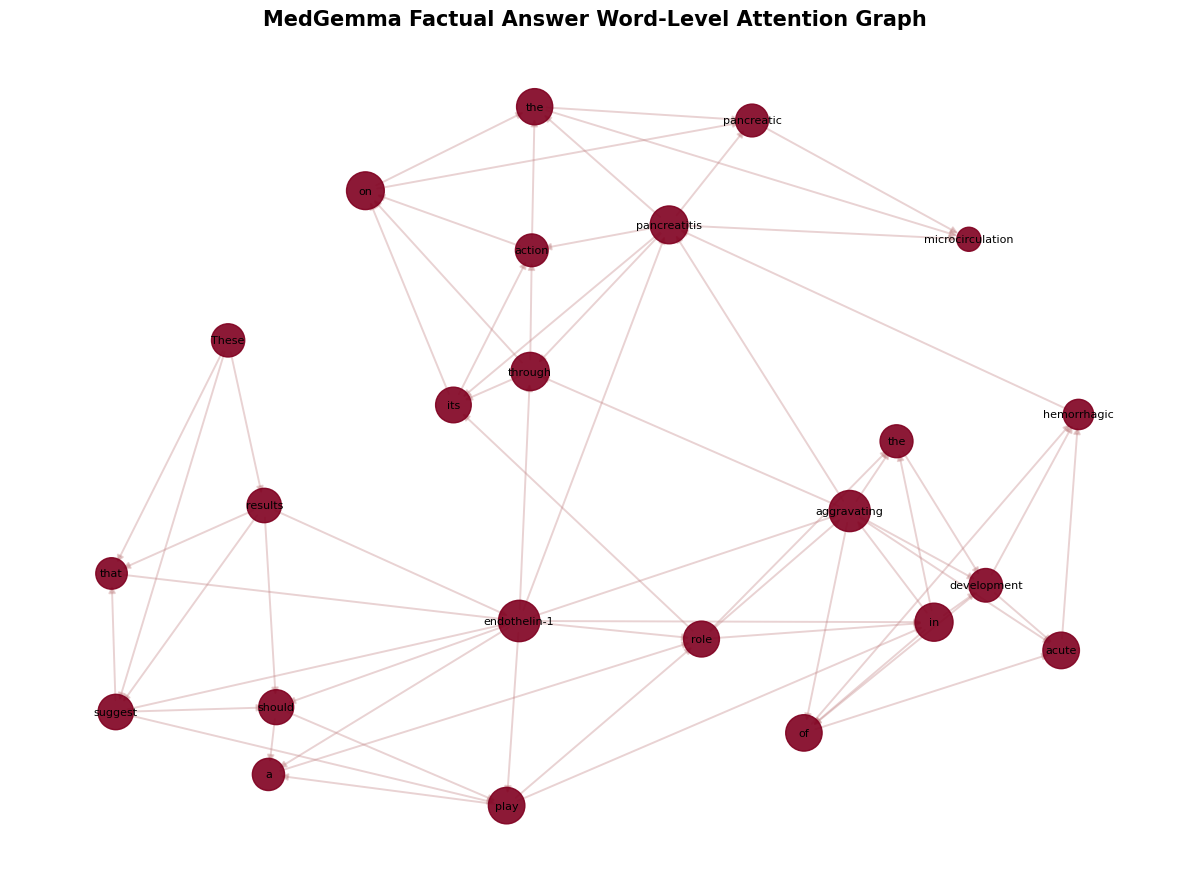

In [50]:
plot_word_graph_colored(
    G_factual_word,
    "MedGemma Factual Answer Word-Level Attention Graph",
    node_color="#800020",   # maroon
    edge_color="#C08081"    # soft maroon/pink
)

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def plot_word_graph_pretty(
    G,
    title,
    node_color="#4B0082",   # default: indigo/purple
    edge_color="#C8A2C8",   # light lavender
    figsize=(14, 10),
    save_path=None
):
    plt.figure(figsize=figsize)

    # Better spacing in layout
    pos = nx.spring_layout(
        G,
        seed=42,
        k=2.2 / np.sqrt(max(len(G.nodes()), 1)),
        iterations=300,
        weight="weight"
    )

    # Out-strength for node sizing
    strength = dict(G.out_degree(weight="weight"))

    # Better node size scaling
    node_sizes = []
    for n in G.nodes():
        s = max(strength[n], 0)
        size = 700 + 2200 * np.sqrt(s)
        node_sizes.append(size)

    # Draw edges first
    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    edge_widths = [1 + 4*w for w in edge_weights]

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=edge_color,
        width=edge_widths,
        alpha=0.30,
        arrows=True,
        arrowsize=14,
        arrowstyle='-|>'
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_color,
        edgecolors="black",
        linewidths=1.2,
        alpha=0.92
    )

    # Labels with white box
    labels = {n: G.nodes[n]["word"] for n in G.nodes()}

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=9,
        font_color="black",
        font_weight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            boxstyle="round,pad=0.2"
        )
    )

    plt.title(title, fontsize=17, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [53]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def plot_word_graph_pretty(
    G,
    title,
    node_color="#14B8A6",
    edge_color="#94A3B8",
    figsize=(16, 11),
    save_path=None
):
    plt.figure(figsize=figsize)

    # Spread nodes farther apart
    pos = nx.spring_layout(
        G,
        seed=42,
        k=1.2,
        iterations=500,
        weight="weight"
    )

    # Weighted out-strength
    strength = dict(
        G.out_degree(weight="weight")
    )

    # Moderate node sizes so labels remain visible
    node_sizes = [
        550 + 1000 * np.sqrt(max(strength[n], 0))
        for n in G.nodes()
    ]

    # Edge widths proportional to attention weight
    edge_weights = [
        G[u][v]["weight"]
        for u, v in G.edges()
    ]

    max_w = max(edge_weights) if edge_weights else 1

    edge_widths = [
        0.6 + 2.2 * (w / max_w)
        for w in edge_weights
    ]

    # Draw edges first
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=edge_color,
        width=edge_widths,
        alpha=0.35,
        arrows=True,
        arrowsize=13,
        arrowstyle="-|>",
        connectionstyle="arc3,rad=0.04"
    )

    # Bright nodes with white border
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_color,
        edgecolors="white",
        linewidths=2,
        alpha=0.95
    )

    # Word labels
    labels = {
        n: G.nodes[n]["word"]
        for n in G.nodes()
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=9,
        font_color="black",
        font_weight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.82,
            boxstyle="round,pad=0.18"
        )
    )

    plt.title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    plt.margins(0.15)
    plt.axis("off")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

    plt.show()

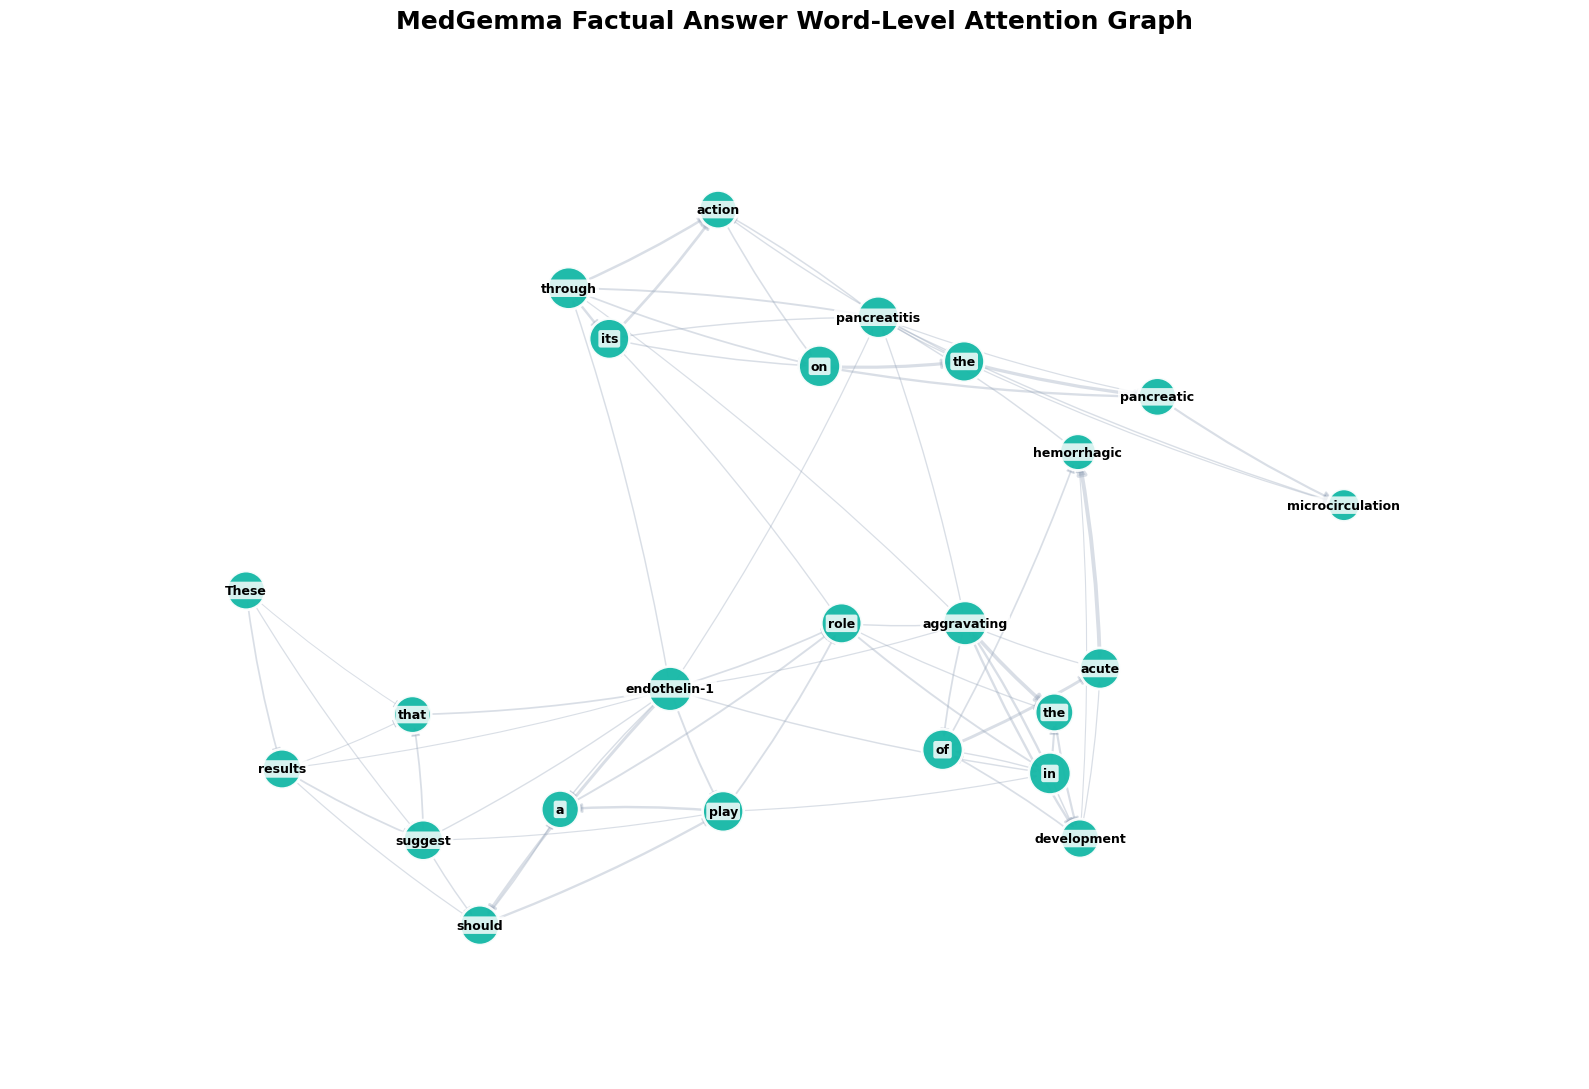

In [54]:
plot_word_graph_pretty(
    G_factual_word,
    "MedGemma Factual Answer Word-Level Attention Graph",
    node_color="#14B8A6",
    edge_color="#94A3B8",
    save_path="/content/MEDH096_factual_pretty.png"
)

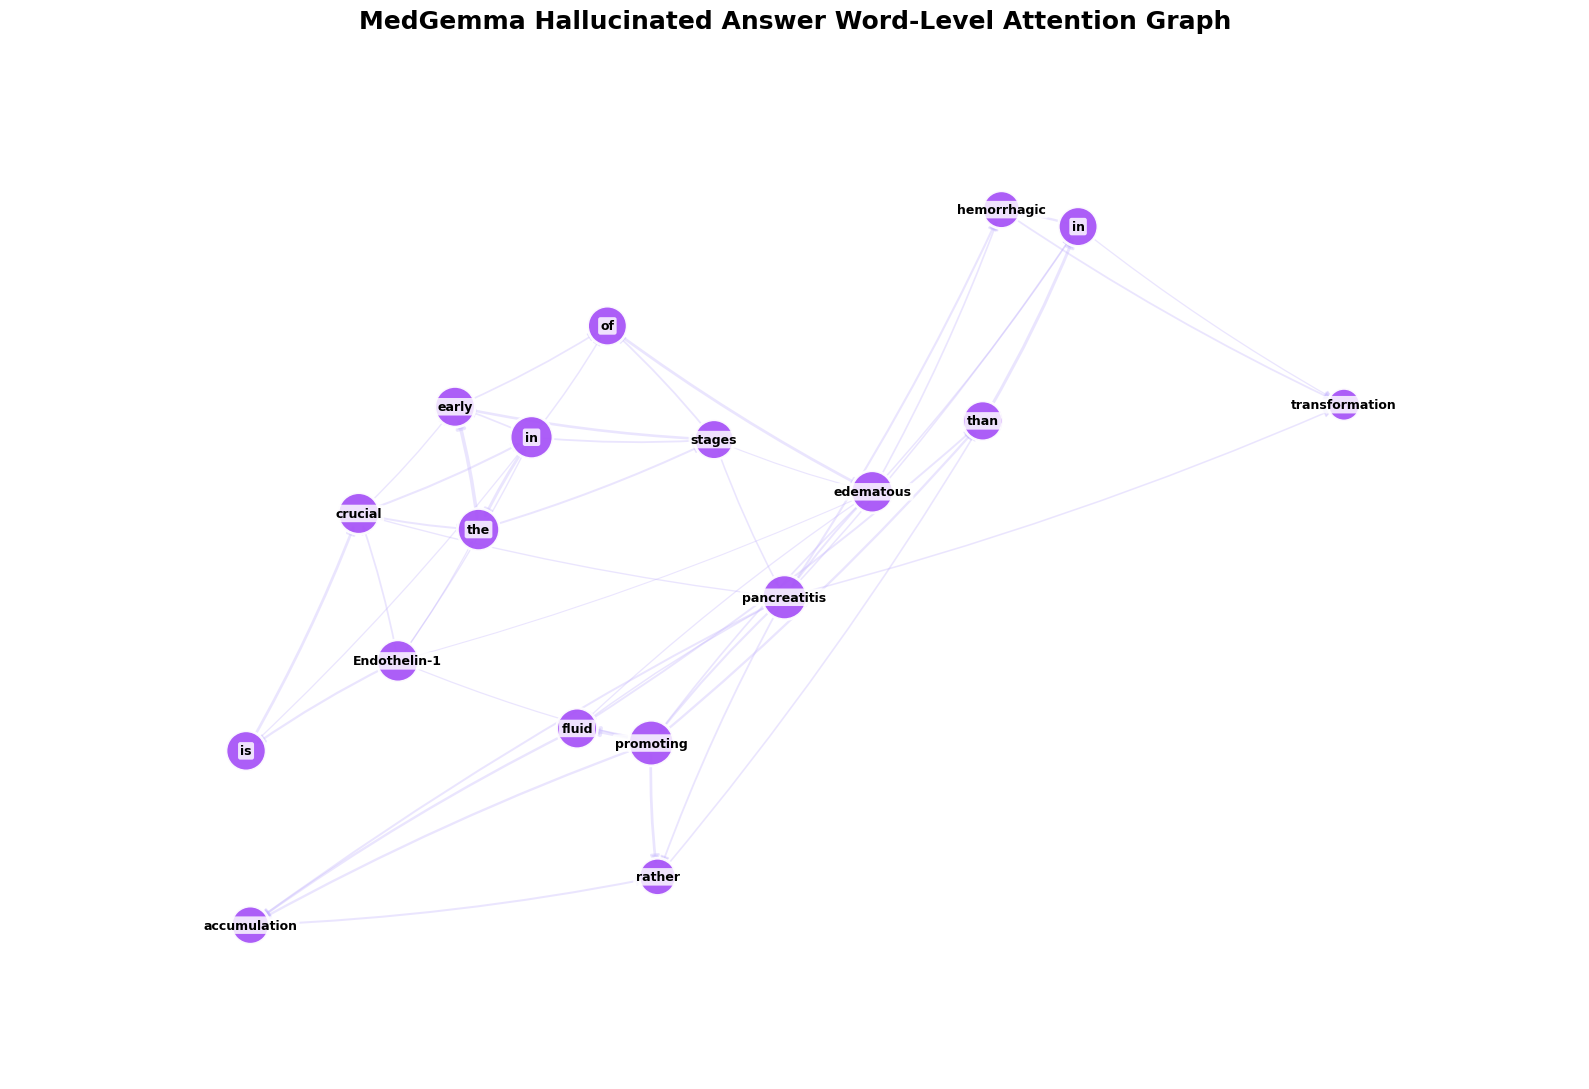

In [55]:
plot_word_graph_pretty(
    G_hall_word,
    "MedGemma Hallucinated Answer Word-Level Attention Graph",
    node_color="#A855F7",
    edge_color="#C4B5FD",
    save_path="/content/MEDH096_hallucinated_pretty.png"
)

In [59]:
from google.colab import files

uploaded = files.upload()

Saving MedHallu_Pilot_200.csv to MedHallu_Pilot_200.csv


In [60]:
import pandas as pd

pilot_df = pd.read_csv(
    "/content/MedHallu_Pilot_200.csv"
)

print("Dataset loaded:", pilot_df.shape)

Dataset loaded: (200, 8)


In [61]:
pair_id = "MEDH_096"

test_pair = (
    pilot_df[pilot_df["Pair_ID"] == pair_id]
    .sort_values("Label")
    .reset_index(drop=True)
)

factual_row = test_pair[
    test_pair["Label"] == 0
].iloc[0]

hallucinated_row = test_pair[
    test_pair["Label"] == 1
].iloc[0]

print("Pair:", pair_id)

print(
    "Same question:",
    factual_row["Question"]
    == hallucinated_row["Question"]
)

print(
    "Factual:",
    factual_row["Response_Type"]
)

print(
    "Hallucinated:",
    hallucinated_row["Response_Type"]
)

Pair: MEDH_096
Same question: True
Factual: Factual
Hallucinated: Hallucinated


In [62]:
from IPython.display import display, HTML

question = str(factual_row["Question"])
factual_answer = str(factual_row["Response"])
hallucinated_answer = str(
    hallucinated_row["Response"]
)

display(HTML(f"""
<div style="
font-family:Arial;
background:white;
border:1px solid #ddd;
border-radius:16px;
padding:26px;
max-width:1000px">

<h2>
🔬 Medical LLM Hallucination Analysis
</h2>

<p style="font-size:17px">
<b>Hugging Face Model:</b>
<code>google/medgemma-4b-it</code>
<br>
<b>Dataset:</b> MedHallu
<br>
<b>Pair ID:</b> MEDH_096
</p>

<hr>

<h3>Biomedical Question</h3>

<div style="
background:#f3f4f6;
padding:14px;
border-radius:9px">
{question}
</div>

<h3 style="color:#0F766E">
✓ Factual Medical Response
</h3>

<div style="
background:#ecfdf5;
padding:14px;
border-radius:9px">
{factual_answer}
</div>

<h3 style="color:#7C3AED">
⚠ Hallucinated Medical Response
</h3>

<div style="
background:#faf5ff;
padding:14px;
border-radius:9px">
{hallucinated_answer}
</div>

<hr>

<h3>Transformer Attention Analysis</h3>

<p style="line-height:1.7">
<b>Model:</b> MedGemma-4B-IT<br>
<b>Transformer layers:</b> 34<br>
<b>Attention heads:</b> 8<br>
<b>Representation:</b> Mean attention from final 4 layers<br>
<b>Graph:</b> Word-level directed attention network<br>
<b>Current stage:</b> Factual vs. hallucinated response analysis
</p>

</div>
"""))

In [63]:
import os

FINAL_DIR = "/content/Notebook3_final_outputs"

print(os.path.exists(FINAL_DIR))

if os.path.exists(FINAL_DIR):
    print(os.listdir(FINAL_DIR))

False


In [64]:
variables = [
    "A_factual_word",
    "A_hall_word",
    "G_factual_word",
    "G_hall_word",
    "factual_words",
    "hall_words",
    "qas_factual",
    "qas_hall"
]

for v in variables:
    print(v, ":", v in globals())

A_factual_word : True
A_hall_word : True
G_factual_word : True
G_hall_word : True
factual_words : True
hall_words : True
qas_factual : True
qas_hall : True


In [65]:
import os
import json
import numpy as np
import pandas as pd
import networkx as nx

FINAL_DIR = "/content/Notebook3_final_outputs"
os.makedirs(FINAL_DIR, exist_ok=True)

# --------------------------------
# 1. Save word-level attention matrices
# --------------------------------

np.save(
    f"{FINAL_DIR}/MEDH096_factual_word_attention.npy",
    A_factual_word
)

np.save(
    f"{FINAL_DIR}/MEDH096_hallucinated_word_attention.npy",
    A_hall_word
)

# --------------------------------
# 2. Save word-level graphs
# --------------------------------

nx.write_graphml(
    G_factual_word,
    f"{FINAL_DIR}/MEDH096_factual_word_graph.graphml"
)

nx.write_graphml(
    G_hall_word,
    f"{FINAL_DIR}/MEDH096_hallucinated_word_graph.graphml"
)

# --------------------------------
# 3. Recreate strength tables
# --------------------------------

def word_strength_table(G):

    rows = []

    for node in G.nodes():

        word = G.nodes[node]["word"]

        out_strength = sum(
            data["weight"]
            for _, _, data
            in G.out_edges(node, data=True)
        )

        in_strength = sum(
            data["weight"]
            for _, _, data
            in G.in_edges(node, data=True)
        )

        rows.append({
            "Position": node,
            "Word": word,
            "Out_Strength": out_strength,
            "In_Strength": in_strength
        })

    return pd.DataFrame(rows)


factual_word_strength = word_strength_table(
    G_factual_word
)

hall_word_strength = word_strength_table(
    G_hall_word
)

factual_word_strength.to_csv(
    f"{FINAL_DIR}/MEDH096_factual_word_strength.csv",
    index=False
)

hall_word_strength.to_csv(
    f"{FINAL_DIR}/MEDH096_hallucinated_word_strength.csv",
    index=False
)

# --------------------------------
# 4. Save QAS
# --------------------------------

qas_df = pd.DataFrame([
    {
        "Pair_ID": "MEDH_096",
        "Response_Type": "Factual",
        **qas_factual
    },
    {
        "Pair_ID": "MEDH_096",
        "Response_Type": "Hallucinated",
        **qas_hall
    }
])

qas_df.to_csv(
    f"{FINAL_DIR}/MEDH096_QAS.csv",
    index=False
)

# --------------------------------
# 5. Save word lists
# --------------------------------

with open(
    f"{FINAL_DIR}/MEDH096_words.json",
    "w"
) as f:

    json.dump(
        {
            "factual_words": factual_words,
            "hallucinated_words": hall_words
        },
        f,
        indent=2
    )

print("Notebook 3 final outputs created.")

Notebook 3 final outputs created.


In [66]:
print(os.path.exists(FINAL_DIR))

print("\nFiles:")
for file in os.listdir(FINAL_DIR):
    print(file)

True

Files:
MEDH096_factual_word_attention.npy
MEDH096_factual_word_graph.graphml
MEDH096_words.json
MEDH096_hallucinated_word_attention.npy
MEDH096_hallucinated_word_graph.graphml
MEDH096_hallucinated_word_strength.csv
MEDH096_factual_word_strength.csv
MEDH096_QAS.csv


In [67]:
!zip -r /content/Notebook3_for_Notebook4.zip \
/content/Notebook3_final_outputs

  adding: content/Notebook3_final_outputs/ (stored 0%)
  adding: content/Notebook3_final_outputs/MEDH096_factual_word_attention.npy (deflated 69%)
  adding: content/Notebook3_final_outputs/MEDH096_factual_word_graph.graphml (deflated 77%)
  adding: content/Notebook3_final_outputs/MEDH096_words.json (deflated 62%)
  adding: content/Notebook3_final_outputs/MEDH096_hallucinated_word_attention.npy (deflated 67%)
  adding: content/Notebook3_final_outputs/MEDH096_hallucinated_word_graph.graphml (deflated 77%)
  adding: content/Notebook3_final_outputs/MEDH096_hallucinated_word_strength.csv (deflated 42%)
  adding: content/Notebook3_final_outputs/MEDH096_factual_word_strength.csv (deflated 43%)
  adding: content/Notebook3_final_outputs/MEDH096_QAS.csv (deflated 27%)


In [68]:
from google.colab import files

files.download(
    "/content/Notebook3_for_Notebook4.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>